In [1]:
import os
import sys
path = os.getcwd()
while True:
    if 'utils.py' in os.listdir(path):
        if path not in sys.path:
            sys.path.append(path)
        break
    new_path = os.path.dirname(path)
    if new_path == path:
        upload_utils = files.upload()
        break
    path = new_path

import utils

Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Llama_3.2_3B_Instruct/Results/checkpoint_mnli_m_Llama_3.2_3B_Instruct_full_zero_shot_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Llama_3.2_3B_Instruct/Results/checkpoint_mnli_m_Llama_3.2_3B_Instruct_full_few_shot_1_examples_entailment_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Llama_3.2_3B_Instruct/Results/checkpoint_mnli_m_Llama_3.2_3B_Instruct_full_few_shot_1_examples_contradiction_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Llama_3.2_3B_Instruct/Results/checkpoint_mnli_m_Llama_3.2_3B_Instruct_full_few_shot_1_examples_neutral_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Llama_3.2_3B

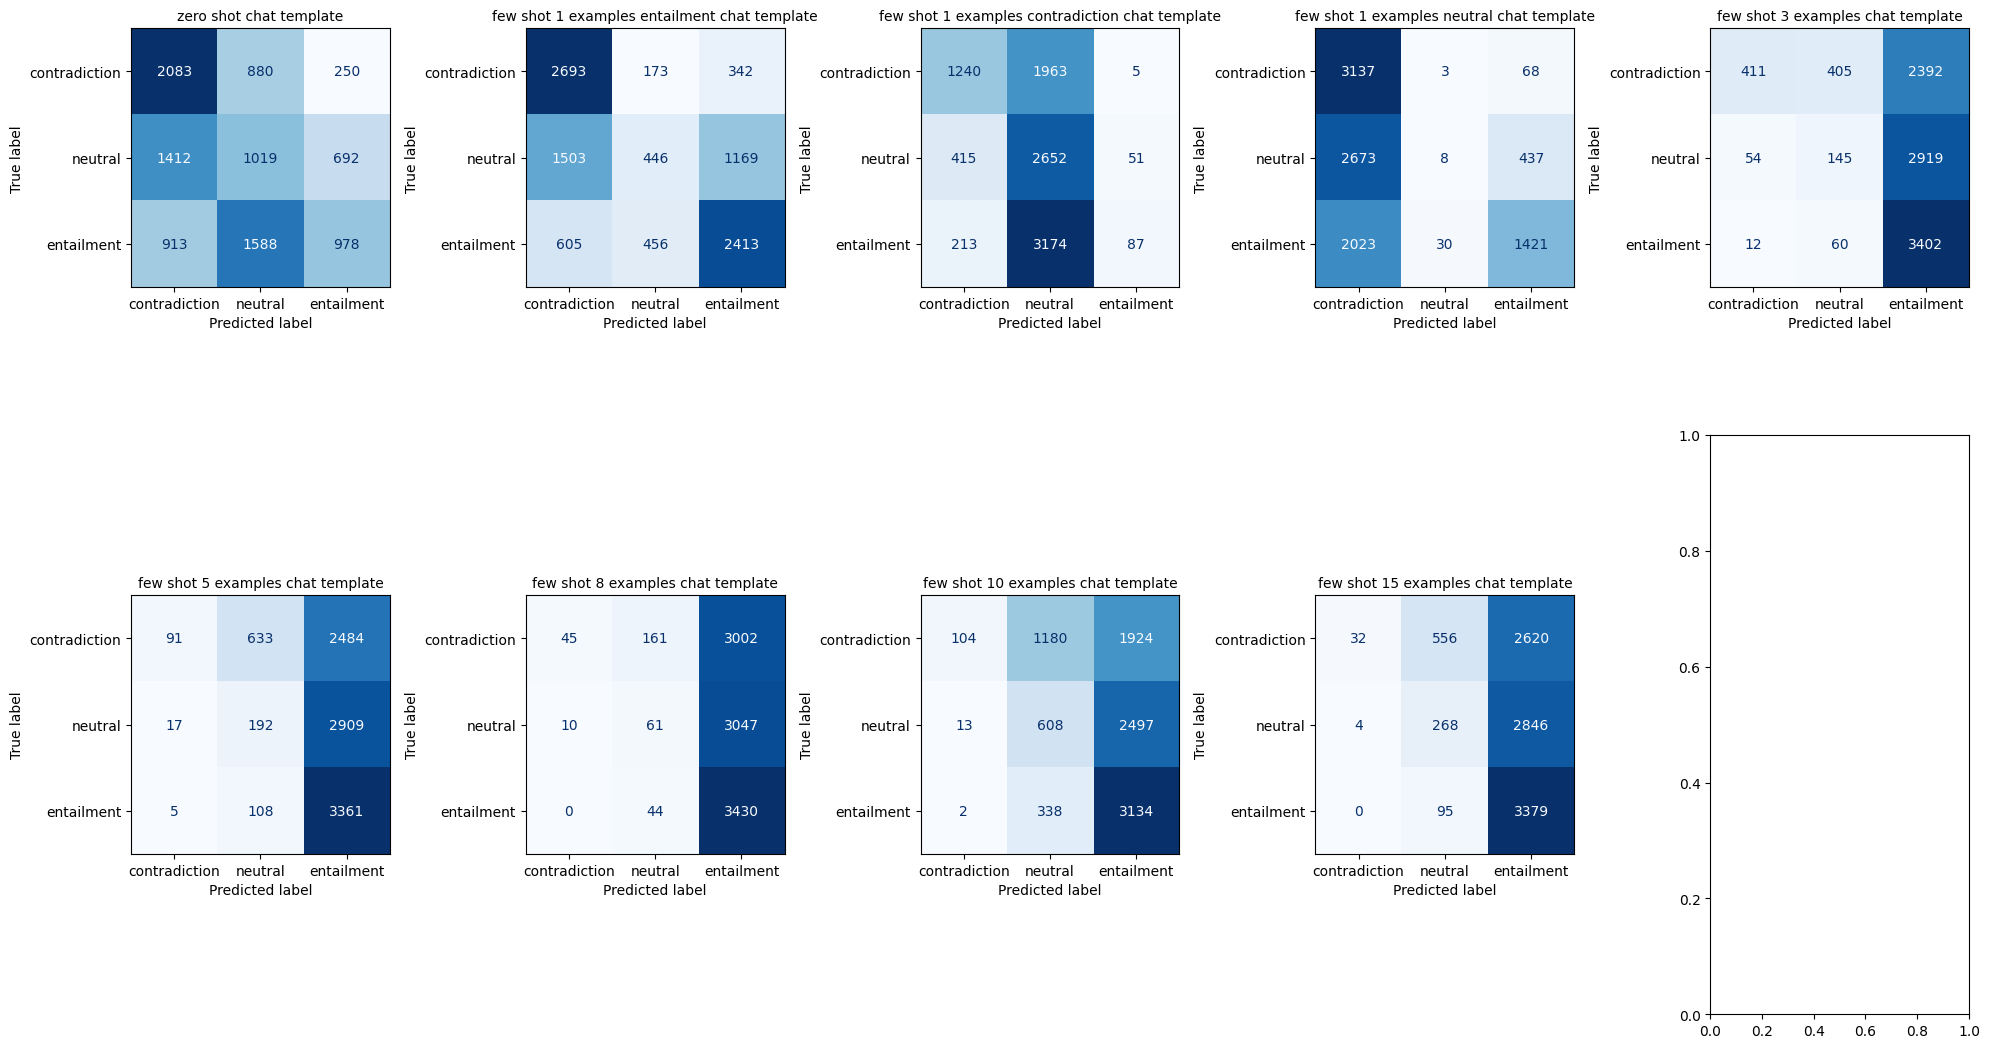

In [3]:
import matplotlib.pyplot as plt

training_modes = [
    'zero shot chat template',
    'few shot 1 examples entailment chat template',
    'few shot 1 examples contradiction chat template',
    'few shot 1 examples neutral chat template',
    'few shot 3 examples chat template',
    'few shot 5 examples chat template',
    'few shot 8 examples chat template',
    'few shot 10 examples chat template',
    'few shot 15 examples chat template'    
]

fig, axes = plt.subplots(2, 5, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

for idx, mode in enumerate(training_modes):
    global_params = {'dataset_type': 'mnli_m',
                'quantization': 'full',
                'training_mode': mode,
                'model_id': 'meta-llama/Llama-3.2-3B-Instruct'}
   
    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
labels = [
    "0 examples",
    "1 example (entailment)",
    "1 example (contradiction)",
    '1 mm example (neutral)',
    "3 examples",
    "5 examples",
    "8 examples",
    "10 examples",
    "15 examples"
]

metrics_df = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
     "F1": f1s,
     "MCC": mccs,
     "Kappa": kappas},
     index= labels
)
metrics_df

,Accuracy,Precision,Recalls,F1,MCC,Kappa
0 examples,0.4157,0.4247,0.4186,0.4058,0.1328,0.1287
1 example (entailment),0.5665,0.5302,0.5590,0.5125,0.3666,0.3460
1 example (contradiction),0.4060,0.5376,0.4207,0.3410,0.1821,0.1259
1 mm example (neutral),0.4659,0.4445,0.4632,0.3665,0.2876,0.1997
3 examples,0.4039,0.4966,0.3846,0.2864,0.1440,0.0816
5 examples,0.3718,0.4650,0.3525,0.2331,0.0589,0.0325
8 examples,0.3608,0.4698,0.3403,0.1977,0.0363,0.0115
10 examples,0.3924,0.5249,0.3765,0.2876,0.0945,0.0706
15 examples,0.3754,0.5208,0.3562,0.2337,0.0712,0.0376


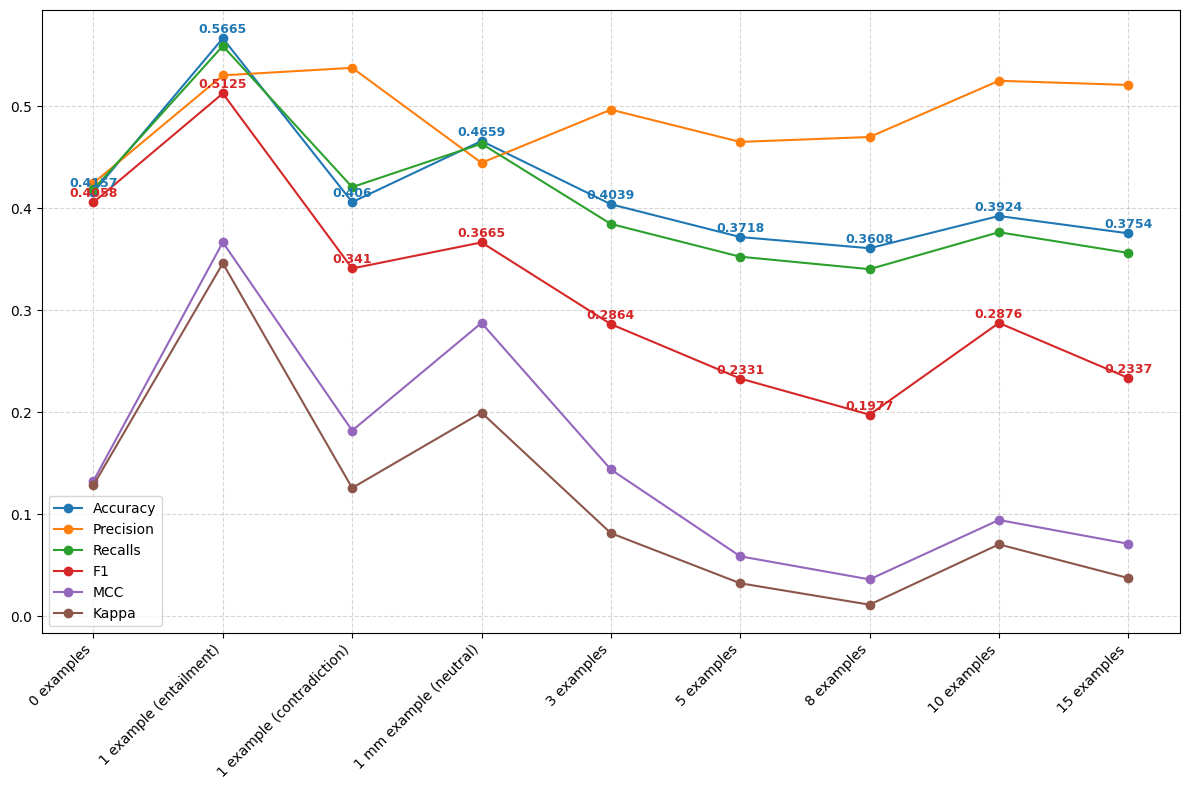

In [6]:
fig, ax = plt.subplots(figsize=(12, 8))

# plot all metrics
metrics_df.plot(kind='line', ax=ax, marker='o')

# set custom x-axis labels
ax.set_xticks(range(len(metrics_df.index)))
ax.set_xticklabels(metrics_df.index, rotation=45, ha='right')

# show grid
ax.grid(True, linestyle='--', alpha=0.5)

# annotate only Accuracy and F1
for metric in ["Accuracy", "F1"]:
    for x, y in enumerate(metrics_df[metric]):
        ax.text(x, y + 0.002, str(y), ha='center', va='bottom', fontsize=9, fontweight='bold', color=ax.get_lines()[list(metrics_df.columns).index(metric)].get_color())

plt.tight_layout()
plt.show()

Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Llama_3.2_3B_Instruct/Results/checkpoint_mnli_mm_Llama_3.2_3B_Instruct_full_zero_shot_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Llama_3.2_3B_Instruct/Results/checkpoint_mnli_mm_Llama_3.2_3B_Instruct_full_few_shot_1_m_examples_entailment_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Llama_3.2_3B_Instruct/Results/checkpoint_mnli_mm_Llama_3.2_3B_Instruct_full_few_shot_1_m_examples_contradiction_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Llama_3.2_3B_Instruct/Results/checkpoint_mnli_mm_Llama_3.2_3B_Instruct_full_few_shot_1_m_examples_neutral_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Ll

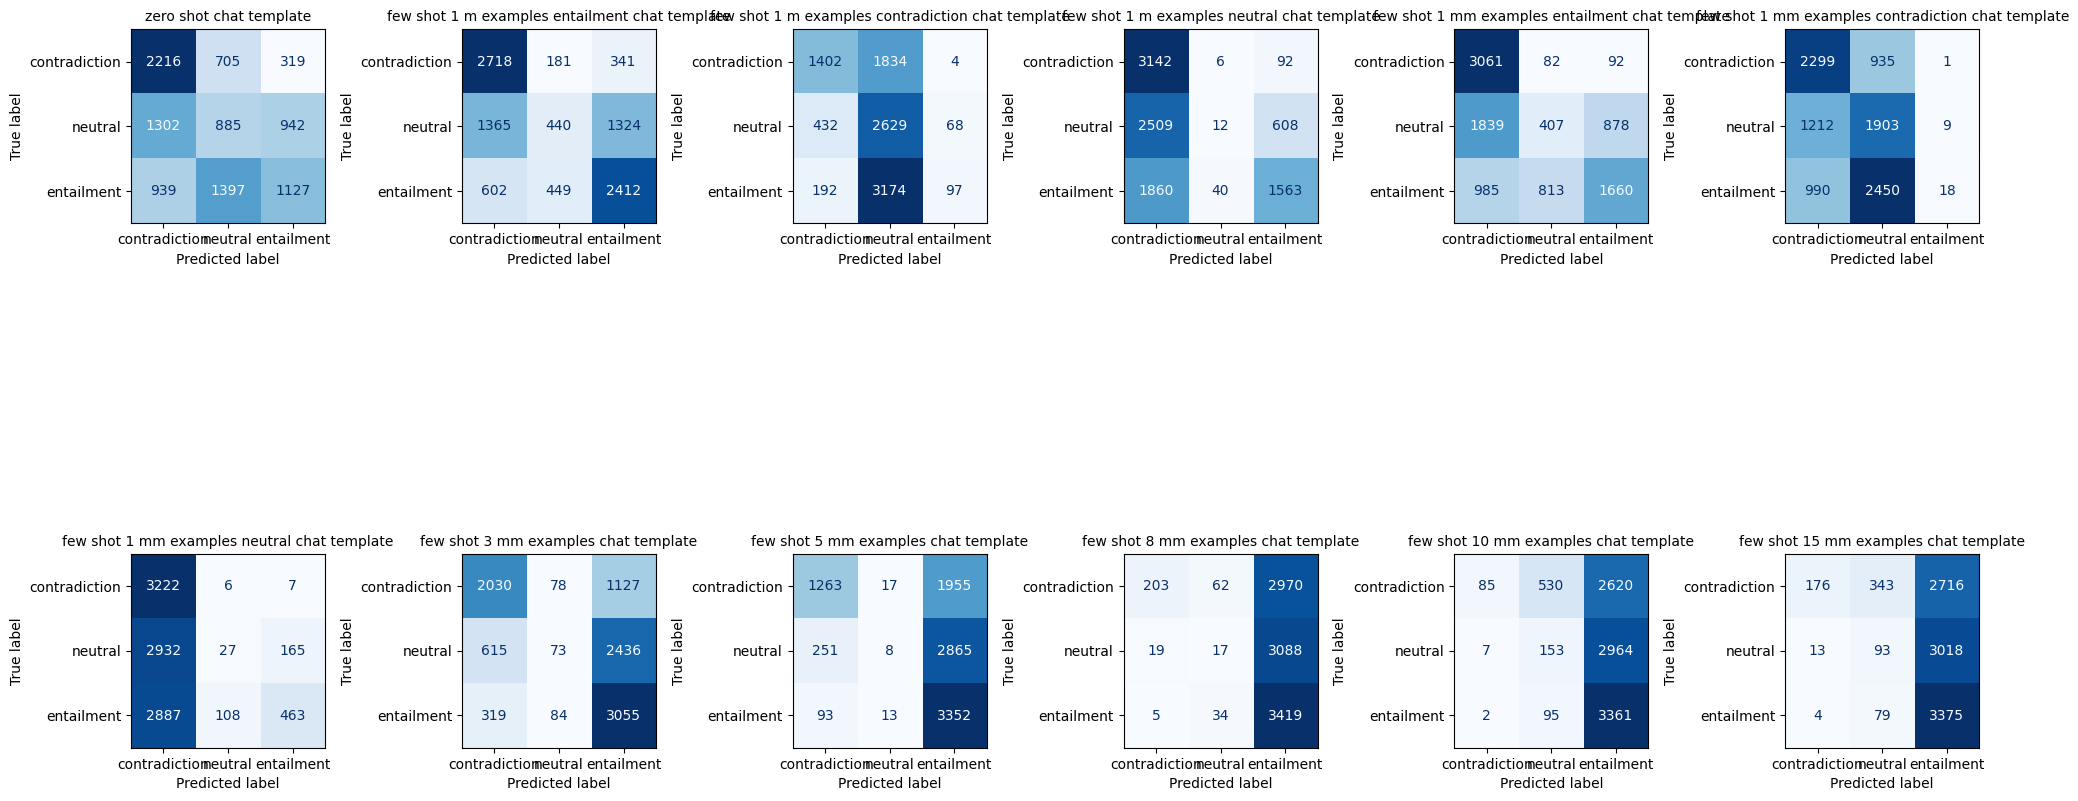

In [10]:
import matplotlib.pyplot as plt

training_modes = [
    'zero shot chat template',
    'few shot 1 m examples entailment chat template',
    'few shot 1 m examples contradiction chat template',
    'few shot 1 m examples neutral chat template',
    'few shot 1 mm examples entailment chat template',
    'few shot 1 mm examples contradiction chat template',
    'few shot 1 mm examples neutral chat template',
    'few shot 3 mm examples chat template',
    'few shot 5 mm examples chat template',
    'few shot 8 mm examples chat template',
    'few shot 10 mm examples chat template',
    'few shot 15 mm examples chat template'    
]

fig, axes = plt.subplots(2, 6, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

for idx, mode in enumerate(training_modes):
    global_params = {'dataset_type': 'mnli_mm',
                'quantization': 'full',
                'training_mode': mode,
                'model_id': 'meta-llama/Llama-3.2-3B-Instruct'}
   
    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
labels = [
    "0 examples",
    "1 m example (entailment)",
    "1 m example (contradiction)",
    '1 m example (neutral)',
    "1 mm example (entailment)",
    "1 mm example (contradiction)",
    '1 mm example (neutral)',
    "3 mm examples",
    "5 mm examples",
    "8 mm examples",
    "10 mm examples",
    "15 mm examples"
]

metrics_df = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
     "F1": f1s,
     "MCC": mccs,
     "Kappa": kappas},
     index= labels
)
metrics_df

,Accuracy,Precision,Recalls,F1,MCC,Kappa
0 examples,0.4300,0.4218,0.4307,0.4168,0.1503,0.1472
1 m example (entailment),0.5665,0.5277,0.5587,0.5118,0.3653,0.3455
1 m example (contradiction),0.4199,0.5367,0.4336,0.3581,0.2033,0.1454
1 m example (neutral),0.4798,0.4386,0.4750,0.3793,0.2949,0.2180
1 mm example (entailment),0.5224,0.4880,0.5188,0.4668,0.3107,0.2827
1 mm example (contradiction),0.4299,0.5045,0.4417,0.3524,0.1844,0.1572
1 mm example (neutral),0.3781,0.4257,0.3795,0.2559,0.1509,0.0707
3 mm examples,0.5254,0.4857,0.5114,0.4349,0.3289,0.2759
5 mm examples,0.4709,0.4689,0.4541,0.3677,0.2836,0.1880
8 mm examples,0.3707,0.4685,0.3523,0.2188,0.0913,0.0298


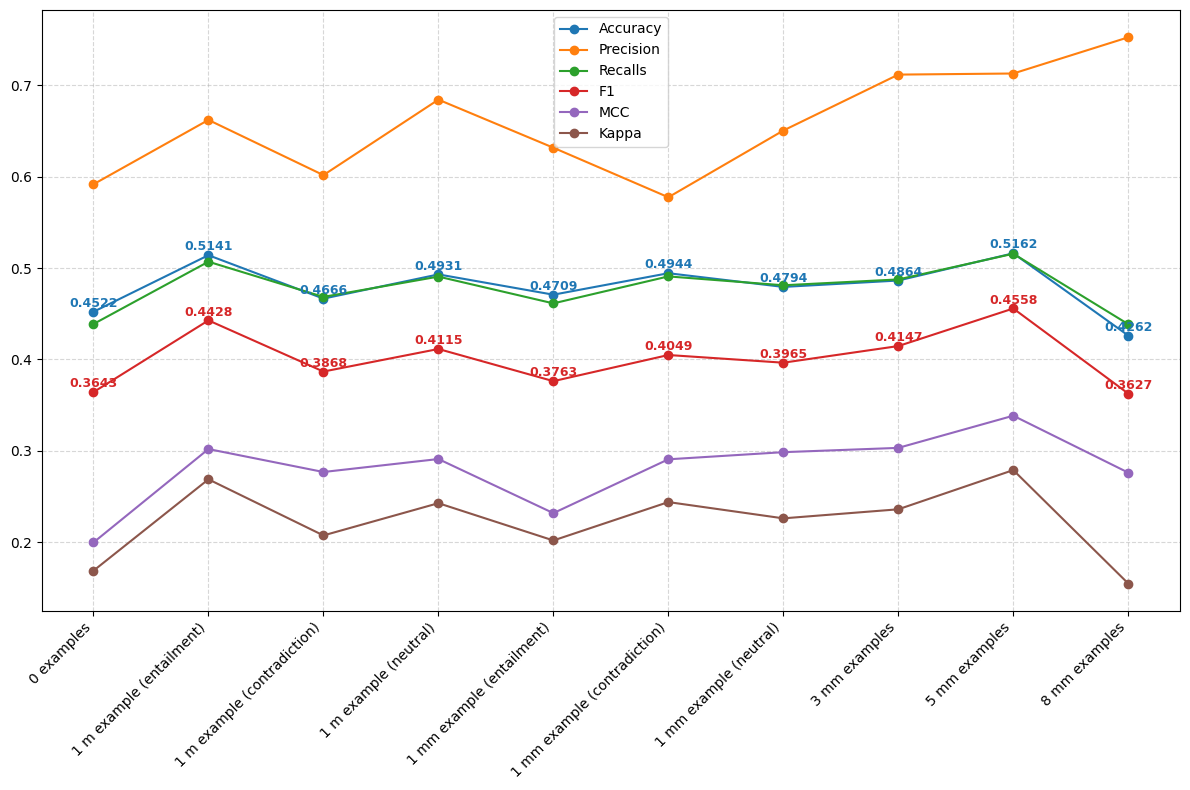

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

# plot all metrics
metrics_df.plot(kind='line', ax=ax, marker='o')

# set custom x-axis labels
ax.set_xticks(range(len(metrics_df.index)))
ax.set_xticklabels(metrics_df.index, rotation=45, ha='right')

# show grid
ax.grid(True, linestyle='--', alpha=0.5)

# annotate only Accuracy and F1
for metric in ["Accuracy", "F1"]:
    for x, y in enumerate(metrics_df[metric]):
        ax.text(x, y + 0.002, str(y), ha='center', va='bottom', fontsize=9, fontweight='bold', color=ax.get_lines()[list(metrics_df.columns).index(metric)].get_color())

plt.tight_layout()
plt.show()